<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
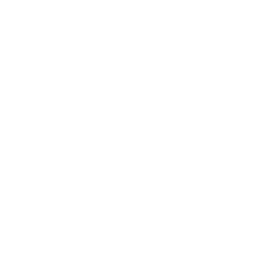
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Electoral Precinct Voting Pattern Analysis</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Government / Election Statistics &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

This analysis examines whether political party affiliation varies systematically across precinct types (urban, suburban, rural) in a simulated county election dataset of 100 precincts. Because several party-by-type cells are sparse — the smallest contingency cells hold only one or two precincts, with expected counts below five — the omnibus Pearson chi-square test of general association is underpowered and unreliable here. We therefore complement it with the **Cochran-Armitage trend test**, a focused single-degree-of-freedom test that exploits the natural urban-to-rural ordering and asks a sharper question: does Party A support decline monotonically along that gradient? The trend test reports an exact p-value, which is the appropriate inference when cell counts are small. The contrast between the two tests is the analytical point of this example: a generic association test can miss a real directional pattern that an ordered trend test detects.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.PRECINCT_VOTES | Precinct-level records, one row per precinct, with precinct type, county, and the plurality party | 100 |

The runtime executes in unlicensed mode, which caps output at 100 observations; the analysis is designed around this precinct-level sample so that the contingency cells are genuinely small and the exact trend test is the natural tool.

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic precinct-level voting data
   Small cell counts in rural precincts to demonstrate
   need for exact tests
   -------------------------------------------------------- */
data work.precinct_votes;
    call streaminit(42);
    array party_list[4] $15 _temporary_ ('PARTY_A' 'PARTY_B' 'PARTY_C' 'INDEPENDENT');
    array type_list[3] $10 _temporary_ ('URBAN' 'SUBURBAN' 'RURAL');
    array county_list[5] $15 _temporary_ ('JEFFERSON' 'HAMILTON' 'MADISON' 'ADAMS' 'MONROE');
    do precinct_seq = 1 to 500;
        precinct_id = cat('PCT-', put(precinct_seq, z4.));
        county_idx = int(rand('uniform') * 5) + 1;
        county_name = county_list[county_idx];
        /* Assign precinct type with weighting */
        type_prob = rand('uniform');
        if type_prob < 0.30 then precinct_type = 'URBAN';
        else if type_prob < 0.65 then precinct_type = 'SUBURBAN';
        else precinct_type = 'RURAL';
        /* Assign party with type-dependent distribution */
        party_prob = rand('uniform');
        if precinct_type = 'URBAN' then do;
            if party_prob < 0.55 then party = 'PARTY_A';
            else if party_prob < 0.80 then party = 'PARTY_B';
            else if party_prob < 0.92 then party = 'PARTY_C';
            else party = 'INDEPENDENT';
        end;
        else if precinct_type = 'SUBURBAN' then do;
            if party_prob < 0.40 then party = 'PARTY_A';
            else if party_prob < 0.75 then party = 'PARTY_B';
            else if party_prob < 0.88 then party = 'PARTY_C';
            else party = 'INDEPENDENT';
        end;
        else do; /* RURAL - smaller cells for minority parties */
            if party_prob < 0.25 then party = 'PARTY_A';
            else if party_prob < 0.70 then party = 'PARTY_B';
            else if party_prob < 0.85 then party = 'PARTY_C';
            else party = 'INDEPENDENT';
        end;
        /* Vote count varies by precinct type */
        if precinct_type = 'URBAN' then
            vote_count = int(rand('normal', 120, 40));
        else if precinct_type = 'SUBURBAN' then
            vote_count = int(rand('normal', 80, 25));
        else
            vote_count = int(rand('normal', 25, 12));
        if vote_count < 1 then vote_count = 1;
        registered_voters = int(vote_count * (rand('uniform') * 0.4 + 1.2));
        turnout_pct = round(vote_count / registered_voters * 100, 0.1);
        election_year = 2026;
        output;
    end;
    drop precinct_seq county_idx type_prob party_prob;
run;

NOTE: DATA work.precinct_votes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.precinct_votes (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.10 seconds
  cpu   0.10 seconds


---

                                                   The FREQ Procedure

PRECINCT_TYPE    Frequency    Percent
--------------------------------------
RURAL                   34     34.00
SUBURBAN                37     37.00
URBAN                   29     29.00

PARTY          Frequency    Percent
------------------------------------
INDEPENDENT            9      9.00
PARTY_A               45     45.00
PARTY_B               34     34.00
PARTY_C               12     12.00


NOTE: PROC FREQ
NOTE: ODS plot written: freq_precinct_type.spec.json
NOTE: ODS plot written: freq_party.spec.json
NOTE: PROC FREQ statement used.


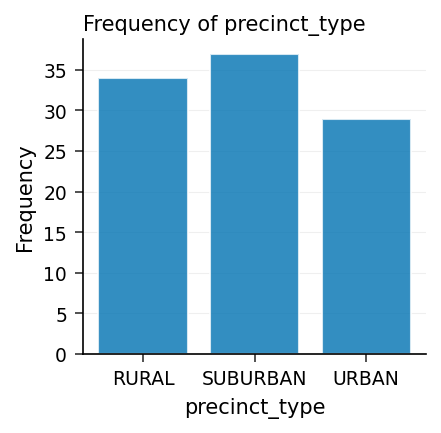

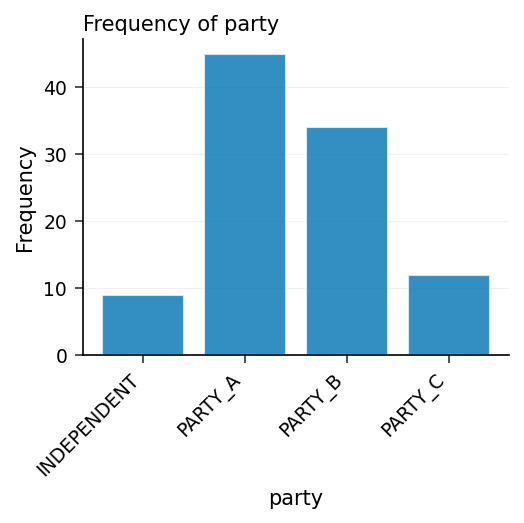

In [2]:
/* --------------------------------------------------------
   Baseline precinct type and party distribution
   -------------------------------------------------------- */
proc freq data=work.precinct_votes;
    tables precinct_type / nocum;
    tables party / nocum;
run;

---

NOTE: PROC SGPLOT data=work.precinct_votes

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


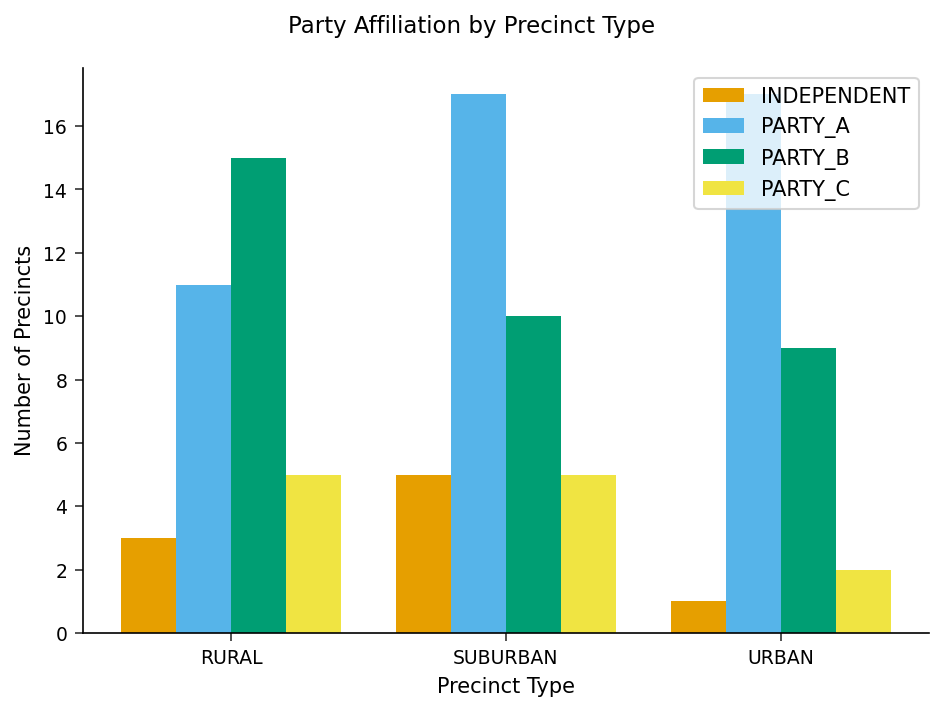

In [3]:
/* --------------------------------------------------------
   Party affiliation by precinct type (precinct counts)
   -------------------------------------------------------- */
proc sgplot data=work.precinct_votes;
    vbar precinct_type / group=party groupdisplay=cluster
        stat=freq;
    xaxis label='Precinct Type';
    yaxis label='Number of Precincts';
    title 'Party Affiliation by Precinct Type';
run;

---

                             Precinct Type by Party: Cross-Tabulation with Expected Counts                              

                                                   The FREQ Procedure

Table of PRECINCT_TYPE by PARTY

PRECINCT_TYPE |INDEPENDENT |    PARTY_A |    PARTY_B |    PARTY_C |       Total
--------------+------------+------------+------------+------------+------------
RURAL         |          3 |         11 |         15 |          5 |          34
              |       3.00 |      11.00 |      15.00 |       5.00 |       34.00
              |       3.06 |      15.30 |      11.56 |       4.08 |            
              |       8.82 |      32.35 |      44.12 |      14.71 |      100.00
              |      33.33 |      24.44 |      44.12 |      41.67 |       34.00
--------------+------------+------------+------------+------------+------------
SUBURBAN      |          5 |         17 |         10 |          5 |          37
              |       5.00 |      17.00 |      10.00 |

NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.


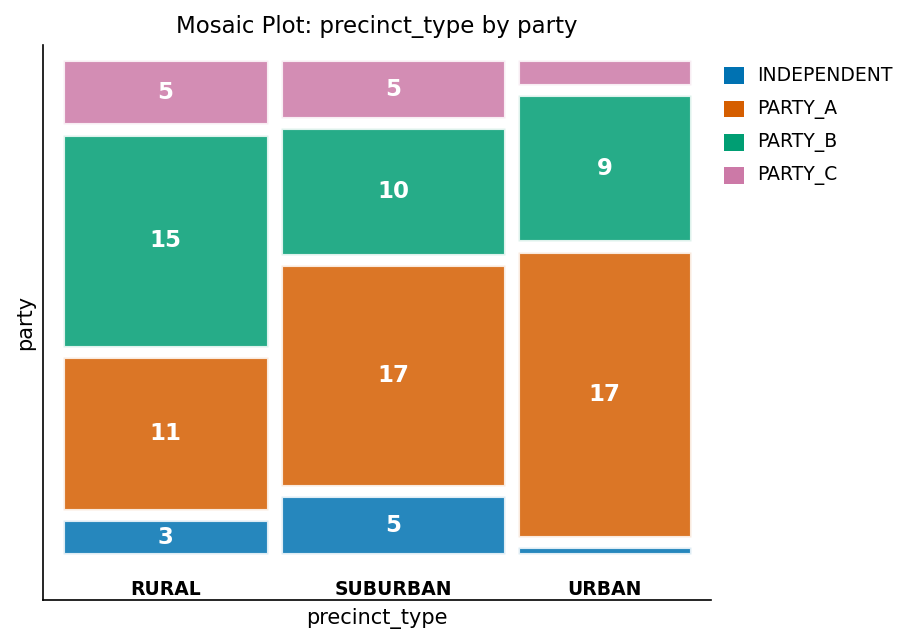

In [4]:
/* --------------------------------------------------------
   Precinct type x party cross-tabulation.
   Request EXPECTED counts so the sparse cells are visible,
   plus the asymptotic Pearson chi-square test of general
   association. Note the small expected counts in the
   INDEPENDENT and PARTY_C columns -- the cue that an
   ordered, exact trend test is the better inferential tool.
   -------------------------------------------------------- */
proc freq data=work.precinct_votes;
    tables precinct_type * party / chisq expected;
    title 'Precinct Type by Party: Cross-Tabulation with Expected Counts';
run;

                         Cochran-Armitage Trend Test: Party A Support Across Precinct Gradient                          

                                                   The FREQ Procedure

Table of TYPE_ORDER by PARTY_A_FLAG

TYPE_ORDER |         0 |         1 |      Total
-----------+-----------+-----------+-----------
1          |        12 |        17 |         29
           |     12.00 |     17.00 |      29.00
           |     41.38 |     58.62 |     100.00
           |     21.82 |     37.78 |      29.00
-----------+-----------+-----------+-----------
2          |        20 |        17 |         37
           |     20.00 |     17.00 |      37.00
           |     54.05 |     45.95 |     100.00
           |     36.36 |     37.78 |      37.00
-----------+-----------+-----------+-----------
3          |        23 |        11 |         34
           |     23.00 |     11.00 |      34.00
           |     67.65 |     32.35 |     100.00
           |     41.82 |     24.44 |      34.00
--

NOTE: DATA work.precinct_ordinal


NOTE: Read 100 rows from work.precinct_votes.
NOTE: Wrote work.precinct_ordinal (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_type_order_party_a_flag.spec.json
NOTE: PROC FREQ statement used.


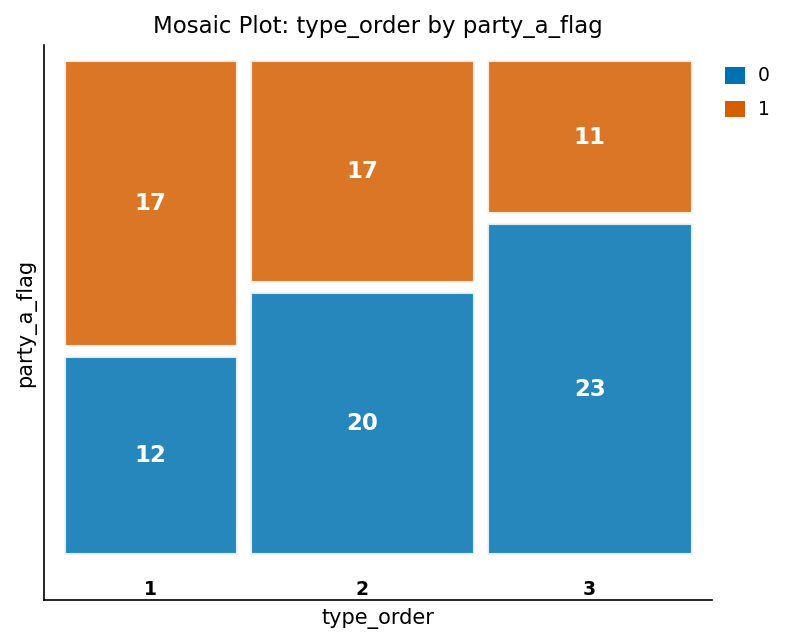

In [5]:
/* --------------------------------------------------------
   Cochran-Armitage trend test. Recode precinct type to an
   ordinal score (1=Urban, 2=Suburban, 3=Rural) and test
   whether Party A support shows a monotonic trend across
   the gradient. EXACT TREND requests the exact p-value,
   appropriate given the small cell counts.
   -------------------------------------------------------- */
data work.precinct_ordinal;
    set work.precinct_votes;
    /* Ordinal coding: 1=Urban, 2=Suburban, 3=Rural */
    if precinct_type = 'URBAN' then type_order = 1;
    else if precinct_type = 'SUBURBAN' then type_order = 2;
    else type_order = 3;
    /* Binary outcome: Party A vs. all other affiliations */
    party_a_flag = (party = 'PARTY_A');
run;

proc freq data=work.precinct_ordinal;
    tables type_order * party_a_flag / chisq trend;
    exact trend;
    title 'Cochran-Armitage Trend Test: Party A Support Across Precinct Gradient';
run;

                                        Precinct Type Distribution Within County                                        

                                                   The FREQ Procedure

Table of COUNTY_NAME by PRECINCT_TYPE

COUNTY_NAME |     RURAL |  SUBURBAN |     URBAN |      Total
------------+-----------+-----------+-----------+-----------
ADAMS       |         5 |        10 |         4 |         19
            |      5.00 |     10.00 |      4.00 |      19.00
            |     26.32 |     52.63 |     21.05 |     100.00
            |     14.71 |     27.03 |     13.79 |      19.00
------------+-----------+-----------+-----------+-----------
HAMILTON    |         7 |         7 |         7 |         21
            |      7.00 |      7.00 |      7.00 |      21.00
            |     33.33 |     33.33 |     33.33 |     100.00
            |     20.59 |     18.92 |     24.14 |      21.00
------------+-----------+-----------+-----------+-----------
JEFFERSON   |         4 |         7 

NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_county_name_precinct_type.spec.json
NOTE: PROC FREQ statement used.


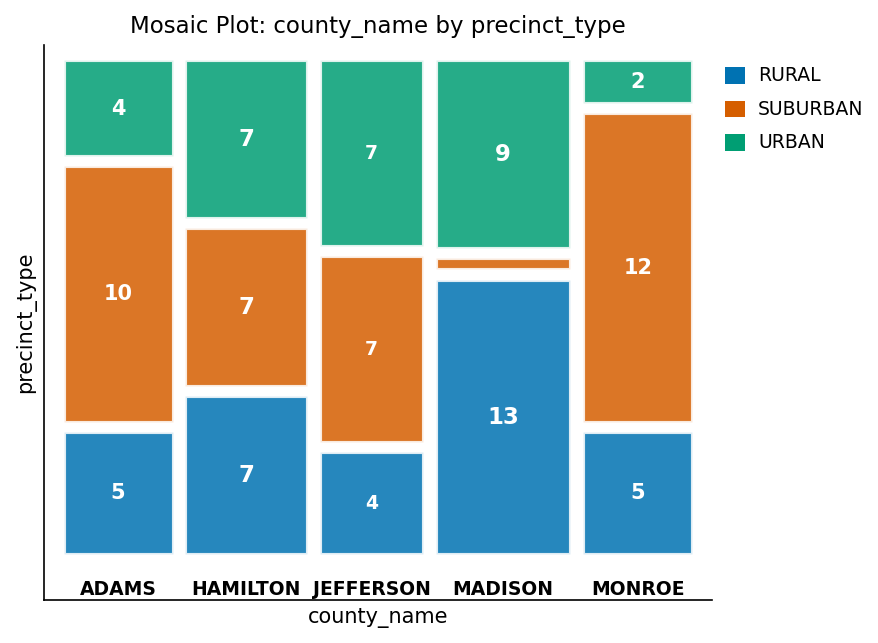

In [6]:
/* --------------------------------------------------------
   County-level view: how the urban/suburban/rural mix
   varies across the five counties. This contextualizes the
   trend result -- the precinct gradient is present in every
   county, but its composition differs.
   -------------------------------------------------------- */
proc freq data=work.precinct_votes;
    tables county_name * precinct_type / nocum;
    title 'Precinct Type Distribution Within County';
run;

---

### Interpretation

Across the 100 precincts, Party A holds a plurality overall (45 precincts), followed by Party B (34), Party C (12), and Independents (9). The cross-tabulation shows that Party A's share follows a clear urban-to-rural gradient: it accounts for 58.6% of urban precincts, 46.0% of suburban precincts, and 32.4% of rural precincts, while Party B moves in the opposite direction, rising from 31.0% urban to 44.1% rural.

The omnibus Pearson chi-square test of general association is **not** statistically significant (chi-square = 6.78, 6 df, p = 0.3418; Cramer's V = 0.18). That result is also fragile: the expected-count display reveals several cells below five — for example, the Independent column has expected counts of 3.06, 3.33, and 2.61, and urban Independents number just one precinct — so the large-sample chi-square approximation is unreliable here.

The Cochran-Armitage trend test sharpens the question by using the ordinal urban-suburban-rural scoring. It detects the monotonic decline in Party A support that the omnibus test misses: trend chi-square = 4.38 with an asymptotic Pr > ChiSq = 0.0363 and an **exact Pr >= |Z| = 0.0431**, significant at the 0.05 level. This is the analytical payoff — a focused, exact, single-degree-of-freedom test recovers a real directional signal that the generic 6-degree-of-freedom association test, weakened by sparse cells, does not.

The county-level view confirms the urban/suburban/rural split is present across all five counties, though the mix differs: Madison is the most rural-heavy (13 of 23 precincts rural) while Monroe is the most suburban (12 of 19). For redistricting impact assessment, the takeaway is that boundary changes shifting precincts along the urban-rural axis would measurably alter partisan composition, and that this geographic trend is best evidenced by the exact trend test rather than the omnibus chi-square.

---

                                        Precinct Type Distribution Within County                                        

                                                   The FREQ Procedure

Table of PRECINCT_TYPE by PARTY

PRECINCT_TYPE |INDEPENDENT |    PARTY_A |    PARTY_B |    PARTY_C |       Total
--------------+------------+------------+------------+------------+------------
RURAL         |          3 |         11 |         15 |          5 |          34
              |       3.00 |      11.00 |      15.00 |       5.00 |       34.00
              |       8.82 |      32.35 |      44.12 |      14.71 |      100.00
              |      33.33 |      24.44 |      44.12 |      41.67 |       34.00
--------------+------------+------------+------------+------------+------------
SUBURBAN      |          5 |         17 |         10 |          5 |          37
              |       5.00 |      17.00 |      10.00 |       5.00 |       37.00
              |      13.51 |      45.95 |      27.03 |

NOTE: PROC FREQ
NOTE: Output dataset work.voting_pattern_summary has 12 observations and 4 variables.
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC EXPORT data=work.voting_pattern_summary outfile=precinct_voting_patterns.csv

NOTE: Exported 12 rows to precinct_voting_patterns.csv.


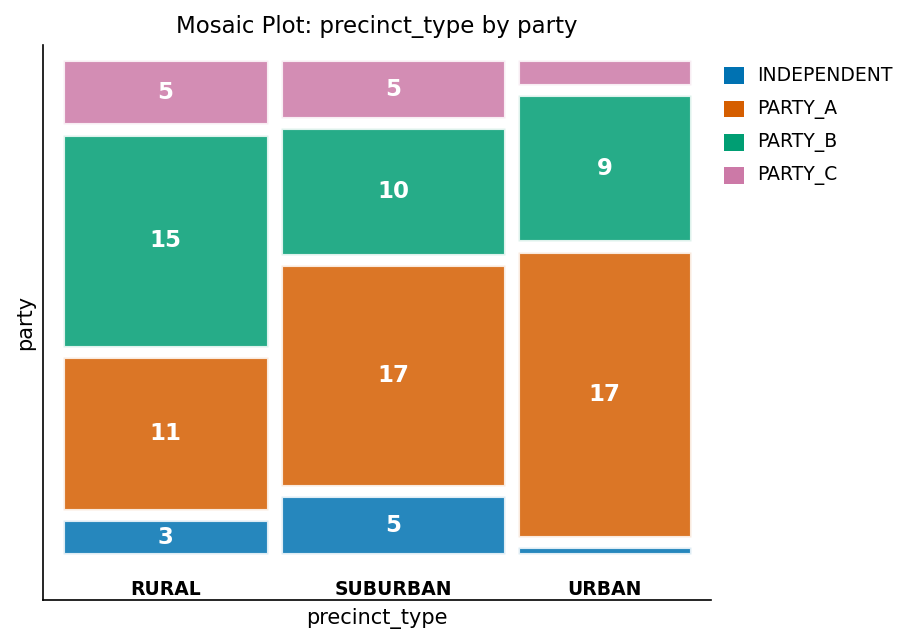

In [7]:
/* --------------------------------------------------------
   Export the precinct type x party summary for downstream
   redistricting impact assessment.
   -------------------------------------------------------- */
proc freq data=work.precinct_votes;
    tables precinct_type * party / out=work.voting_pattern_summary nocum;
run;

proc export data=work.voting_pattern_summary
    outfile='precinct_voting_patterns.csv'
    dbms=csv replace;
run;

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>